<a href="https://colab.research.google.com/github/portfafolioJesus/juegosAjedrez/blob/main/aseguradora_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de costos médicos — Aseguradora
Integrante: Jesús

Objetivos: limpiar el dataset, explorar qué encarece un seguro, segmentar a los clientes con k-means y entrenar modelos para predecir el costo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix, silhouette_score,
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score)

pd.set_option('display.max_columns', None)
df = pd.read_csv('/content/aseguradora.csv')

## ¿Cómo viene el dataset?
Reviso cuántos registros hay, qué columnas trae y si faltan datos.

In [5]:
print(df.shape)
df.info()
df.head()

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   edad            1338 non-null   int64  
 1   sexo            1338 non-null   object 
 2   imc             1338 non-null   float64
 3   hijos           1338 non-null   int64  
 4   fumador         1338 non-null   object 
 5   region          1338 non-null   object 
 6   costos_medicos  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,edad,sexo,imc,hijos,fumador,region,costos_medicos
0,19,mujer,27.90,0,yes,poniente_alto,1.688492e+07
1,18,hombre,33.77,1,no,cordillera,1.725552e+03
2,28,hombre,33.00,3,no,cordillera,4.449462e+06
3,33,hombre,22705.00,0,no,poniente_alto,2.198447e+04
4,32,hombre,28.88,0,no,poniente_alto,3.866855e+03


1338 asegurados y 7 variables, sin valores nulos. Las columnas numéricas son edad, imc, hijos y costos_medicos; las de texto son sexo, fumador y region. Estas tres habrá que convertirlas a número antes de modelar.

In [6]:
# variables derivadas: fumador en 0/1 (para correlaciones) y edad relativa al promedio
df['fumador_mapped'] = df['fumador'].map({'yes': 1, 'no': 0})
df['edad_diff'] = df['edad'] - df['edad'].mean()

## ¿Hay valores extremos que distorsionen el análisis?
Un IMC sobre 60 es imposible en la práctica, y unos pocos costos muy altos inflan promedios y correlaciones. Elimino los IMC > 60 y el 1% más alto de costos.

In [7]:
n0 = len(df)
df_clean = df[df['imc'] <= 60].copy()

p99 = df_clean['costos_medicos'].quantile(0.99)
df_clean = df_clean[df_clean['costos_medicos'] <= p99].copy()

print(f'Filas: {n0} -> {len(df_clean)}  (eliminadas {n0 - len(df_clean)})')

Filas: 1338 -> 1010  (eliminadas 328)


Se eliminaron 328 filas (24,5% del total): 1338 → 1010. La mayoría (317) tenían IMC > 60, valores imposibles que apuntan a errores de carga. El resto fue el 1% de costos más extremos.

## ¿Los fumadores cuestan más que los no fumadores?
Comparo el costo promedio de ambos grupos.

fumador
no     2274593.0
yes    6368120.0
Name: costos_medicos, dtype: float64


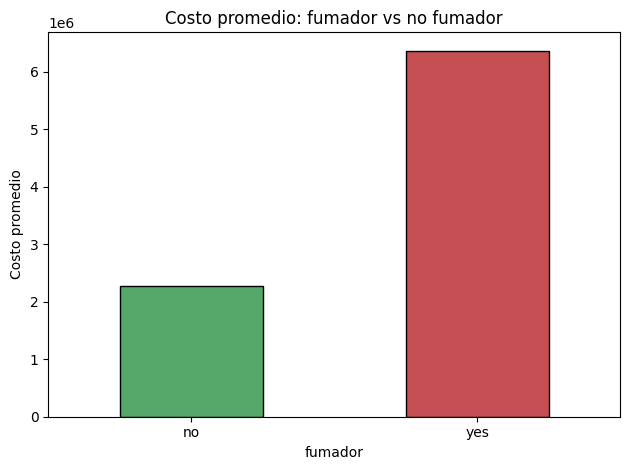

In [8]:
costo_fumador = df_clean.groupby('fumador')['costos_medicos'].mean()
print(costo_fumador.round(0))

costo_fumador.plot(kind='bar', color=['#55A868', '#C44E52'], edgecolor='black')
plt.title('Costo promedio: fumador vs no fumador')
plt.ylabel('Costo promedio'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

Sí, y por mucho: los fumadores cuestan en promedio 2,8 veces más. Es la diferencia más marcada del dataset y el factor individual que más encarece un seguro.

## ¿Un IMC alto implica costo alto?
Divido a los asegurados en IMC alto/bajo (sobre la mediana) y veo qué porcentaje de cada grupo cae en costo alto.

In [9]:
med_imc = df_clean['imc'].median()
med_costo = df_clean['costos_medicos'].median()
df_clean['imc_alto'] = df_clean['imc'] > med_imc
df_clean['costo_alto'] = df_clean['costos_medicos'] > med_costo

print(f'Mediana IMC: {med_imc:.1f}  |  Mediana costo: {med_costo:,.0f}')
print((df_clean.groupby('imc_alto')['costo_alto'].mean() * 100).round(1))

Mediana IMC: 30.6  |  Mediana costo: 17,548
imc_alto
False    48.7
True     51.3
Name: costo_alto, dtype: float64


Casi nada: el IMC alto coincide con costo alto solo el 51% de las veces, apenas mejor que el azar. Por sí solo no separa a los caros de los baratos. Esto no significa que el IMC no importe, sino que su efecto no es lineal, algo que el modelo confirma más adelante.

## ¿El IMC se reparte distinto entre fumadores y no fumadores?
Superpongo las dos distribuciones para ver si fumar va de la mano con un IMC distinto.

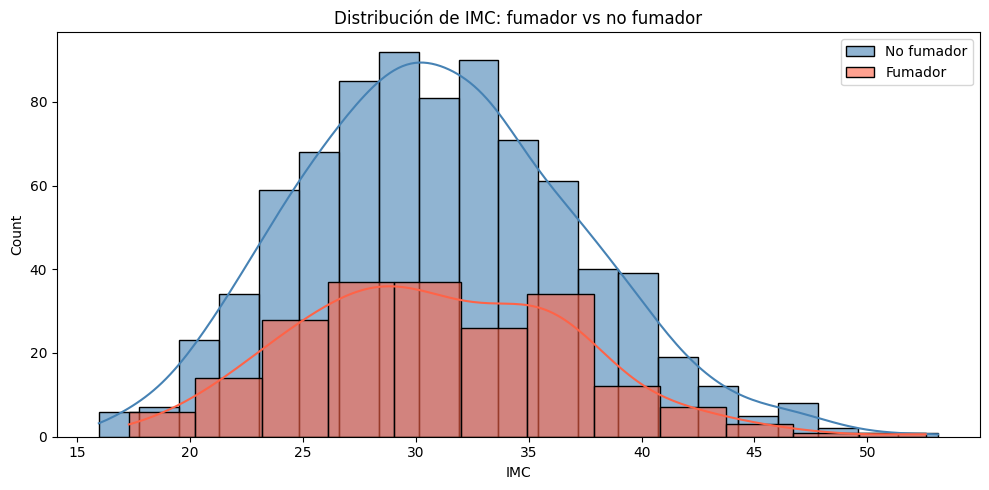

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean['fumador']=='no']['imc'], color='steelblue',
             label='No fumador', kde=True, alpha=0.6)
sns.histplot(df_clean[df_clean['fumador']=='yes']['imc'], color='tomato',
             label='Fumador', kde=True, alpha=0.6)
plt.title('Distribución de IMC: fumador vs no fumador')
plt.xlabel('IMC'); plt.legend()
plt.tight_layout(); plt.show()

Las dos distribuciones son casi idénticas: fumadores y no fumadores tienen el mismo perfil de IMC. Son factores de riesgo independientes, así que entran por separado al modelo.

## ¿Qué región concentra más asegurados y más costo alto?
Cuento asegurados por región y calculo qué porcentaje de cada una cae en costo alto.

region
poniente_alto       488
cordillera          360
cordillera_norte    162
Name: count, dtype: int64

% de costo alto por región:
region
cordillera          35.0
cordillera_norte    33.3
poniente_alto       66.6
Name: costo_alto, dtype: float64


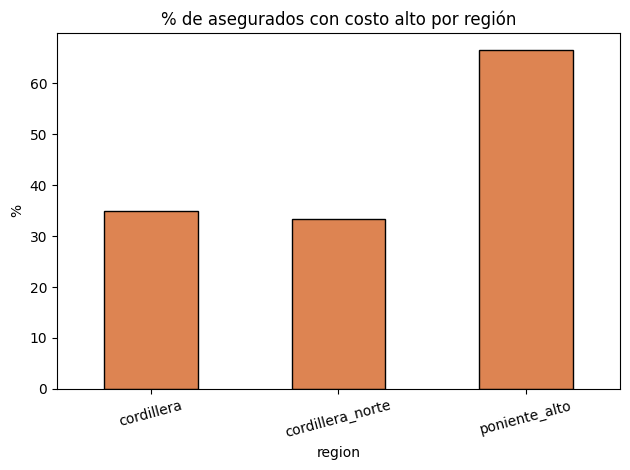

In [11]:
print(df_clean['region'].value_counts())

tasa = (df_clean.groupby('region')['costo_alto'].mean() * 100).round(1)
print('\n% de costo alto por región:')
print(tasa)

tasa.plot(kind='bar', color='#DD8452', edgecolor='black')
plt.title('% de asegurados con costo alto por región')
plt.ylabel('%'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

Poniente_alto destaca: concentra el 48% de los asegurados y el 67% de ellos cae en costo alto, contra ~34% en las otras dos regiones. La zona geográfica marca una diferencia clara en el costo.

## ¿Qué variables se relacionan linealmente con el costo?
Un mapa de calor de correlaciones de Pearson para ver qué se mueve junto al costo de forma lineal. Codifico las categóricas a número para poder incluirlas.

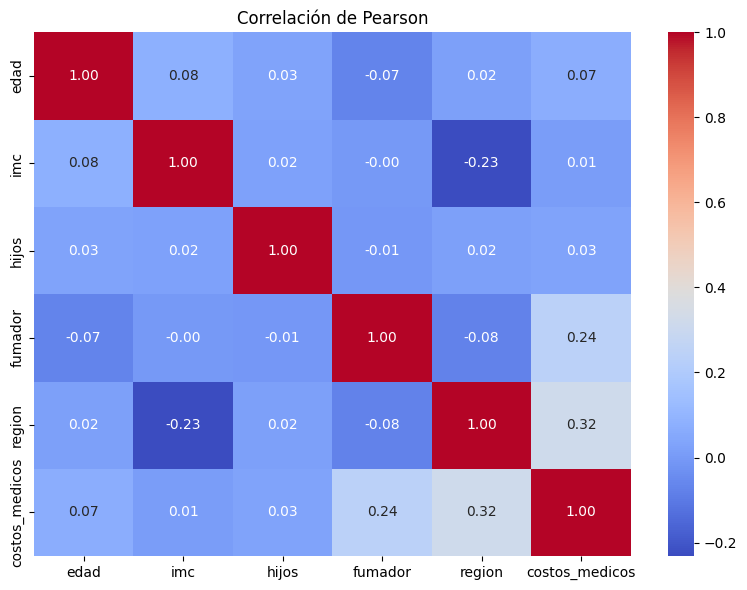

In [12]:
df_enc = df_clean.copy()
le = LabelEncoder()
for c in ['sexo', 'fumador', 'region']:
    df_enc[c] = le.fit_transform(df_clean[c])

corr = df_enc[['edad', 'imc', 'hijos', 'fumador', 'region', 'costos_medicos']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación de Pearson')
plt.tight_layout(); plt.show()

Las correlaciones lineales con el costo son todas bajas: región (0,32) y fumar (0,24) encabezan; edad, IMC e hijos rondan cero. Pearson solo capta relaciones lineales: que el IMC dé cerca de cero no significa que no influya, sino que su efecto no es una línea recta. El modelo de más abajo, que sí capta no-linealidades, le da un peso muy distinto.

---
## Segmentación de clientes con K-Means

### ¿Existen grupos naturales de asegurados, más allá de caro/barato?
Busco perfiles agrupando por edad, IMC, hijos, costo y si fuman. K-means usa distancias, así que escalo las variables: sin escalar, el costo dominaría por su magnitud. Primero el método del codo para elegir cuántos grupos.

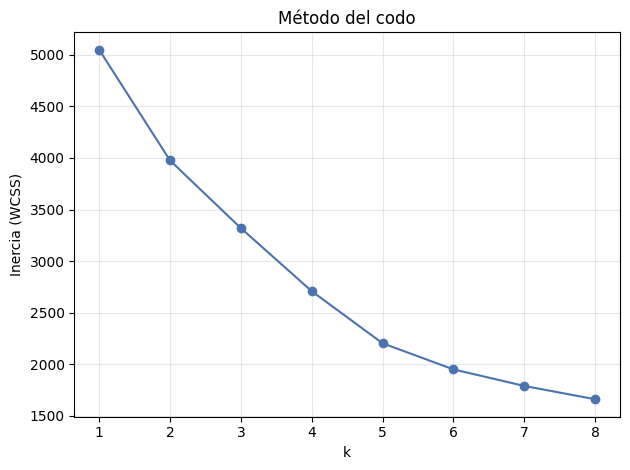

In [13]:
X_cluster = df_clean[['edad', 'imc', 'hijos', 'costos_medicos']].copy()
X_cluster['fumador'] = df_clean['fumador'].map({'yes': 1, 'no': 0})
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

inercias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster_scaled).inertia_
            for k in range(1, 9)]

plt.plot(range(1, 9), inercias, marker='o', color='#4C72B0')
plt.title('Método del codo'); plt.xlabel('k'); plt.ylabel('Inercia (WCSS)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

El codo no es muy marcado, pero la caída se suaviza a partir de k=3, así que elijo tres grupos. Entreno k-means con ese valor y reviso el perfil de cada grupo.

In [14]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print('Silueta:', round(silhouette_score(X_cluster_scaled, df_clean['cluster']), 3))

perfil_clusters = df_clean.groupby('cluster').agg(
    n_asegurados   = ('cluster', 'size'),
    edad_promedio  = ('edad', 'mean'),
    imc_promedio   = ('imc', 'mean'),
    costo_promedio = ('costos_medicos', 'mean'),
    pct_fumadores  = ('fumador', lambda s: (s == 'yes').mean() * 100),
).round(1).reset_index()
print(perfil_clusters)

Silueta: 0.221
   cluster  n_asegurados  edad_promedio  imc_promedio  costo_promedio  \
0        0           358           26.1          29.9        897262.1   
1        1           446           50.3          31.9       3380164.4   
2        2           206           37.1          31.0       6368119.5   

   pct_fumadores  
0            0.0  
1            0.0  
2          100.0  


K-means encontró tres perfiles, y el algoritmo separó a los fumadores en su propio grupo:

- Grupo 0 (358 personas): jóvenes (~26 años), no fuman, costo más bajo.
- Grupo 1 (446 personas): mayores (~50 años), no fuman, costo medio.
- Grupo 2 (206 personas): 100% fumadores (~37 años), costo más alto.

Entre los no fumadores, la edad marcó la división. La silueta (0,22) es modesta, coherente con que el codo tampoco era marcado: los grupos existen pero no están bien separados.

---
## Modelo de clasificación

### ¿Puedo predecir si un asegurado saldrá caro o barato antes de aceptarlo?
Entreno un Random Forest para clasificar costo alto/bajo. Preparo las variables: las binarias (sexo, fumador) van a 0/1, y region a one-hot, porque tiene 3 categorías sin orden y un LabelEncoder le impondría un orden falso.

In [15]:
df_modelo = df_clean.copy()
df_modelo['sexo'] = df_modelo['sexo'].map({'hombre': 0, 'mujer': 1})
df_modelo['fumador'] = df_modelo['fumador'].map({'no': 0, 'yes': 1})
df_modelo = pd.get_dummies(df_modelo, columns=['region'], prefix='region', dtype=int)

region_cols = [c for c in df_modelo.columns if c.startswith('region_')]
feature_cols = ['edad', 'sexo', 'imc', 'hijos', 'fumador'] + region_cols

X = df_modelo[feature_cols]
y = df_modelo['costo_alto'].astype(int)
print('Variables:', feature_cols)

Variables: ['edad', 'sexo', 'imc', 'hijos', 'fumador', 'region_cordillera', 'region_cordillera_norte', 'region_poniente_alto']


In [16]:
# stratify mantiene la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

              precision    recall  f1-score   support

  Costo Bajo       0.72      0.75      0.73       101
  Costo Alto       0.74      0.70      0.72       101

    accuracy                           0.73       202
   macro avg       0.73      0.73      0.73       202
weighted avg       0.73      0.73      0.73       202



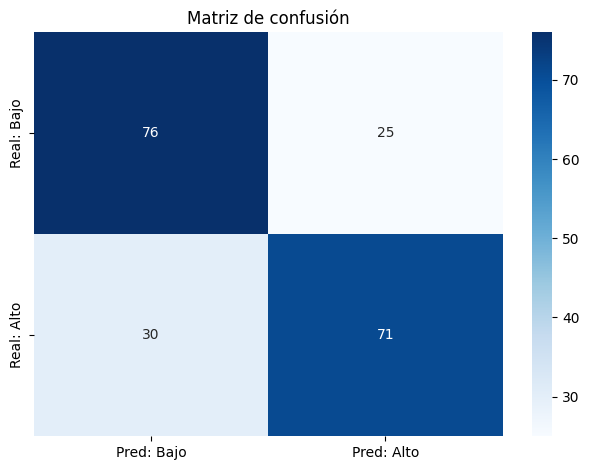

In [17]:
print(classification_report(y_test, y_pred, target_names=['Costo Bajo', 'Costo Alto']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Bajo', 'Pred: Alto'],
            yticklabels=['Real: Bajo', 'Real: Alto'])
plt.title('Matriz de confusión'); plt.tight_layout(); plt.show()

Accuracy de 0,73, un rendimiento moderado: acierta en 7 de cada 10 casos. La matriz de confusión muestra que los errores se reparten parejo entre falsos altos y falsos bajos, sin sesgo hacia una clase. Sirve como filtro inicial, no como decisión final.

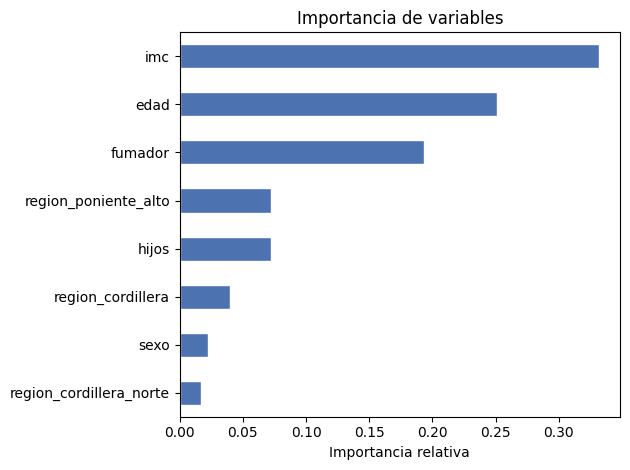

imc                        0.332
edad                       0.251
fumador                    0.193
region_poniente_alto       0.073
hijos                      0.072
region_cordillera          0.040
sexo                       0.022
region_cordillera_norte    0.017
dtype: float64


In [18]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()

importancias.plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.title('Importancia de variables'); plt.xlabel('Importancia relativa')
plt.tight_layout(); plt.show()
print(importancias.sort_values(ascending=False).round(3))

Las tres variables que más pesan son IMC, edad y fumar, en ese orden. El IMC encabeza pese a su correlación lineal casi nula con el costo: el modelo capta que su efecto es no lineal. Las columnas de región aportan poco una vez que están IMC, edad y tabaquismo.

---
## Modelo de regresión

### ¿Puedo predecir el monto exacto del costo, no solo alto/bajo?
Mismo set de variables, pero ahora el objetivo es costos_medicos (un número continuo). Lo evalúo con MAE (error promedio), RMSE (penaliza errores grandes) y R² (qué porcentaje de la variación explica).

In [19]:
y_reg = df_modelo['costos_medicos']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

modelo_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_reg.fit(Xr_train, yr_train)
yr_pred = modelo_reg.predict(Xr_test)

print(f'MAE:  {mean_absolute_error(yr_test, yr_pred):,.0f}')
print(f'RMSE: {mean_squared_error(yr_test, yr_pred) ** 0.5:,.0f}')
print(f'R2:   {r2_score(yr_test, yr_pred):.3f}')

MAE:  3,076,985
RMSE: 5,197,634
R2:   0.216


R² de apenas 0,22: el modelo explica solo el 22% de la variación del costo, un ajuste pobre. Predecir el monto exacto resulta mucho más difícil que clasificar alto/bajo. Para ver dónde falla, grafico el error contra el costo real.

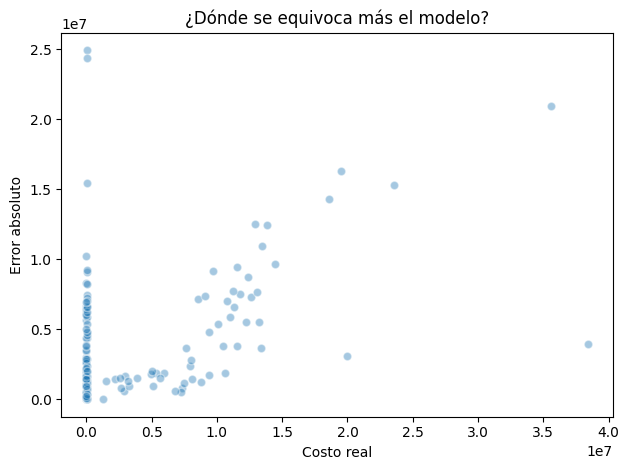

Error medio en costos bajos: 1,659,082
Error medio en costos altos: 4,494,887


In [20]:
error = np.abs(yr_test.values - yr_pred)

plt.scatter(yr_test.values, error, alpha=0.4, edgecolor='white')
plt.xlabel('Costo real'); plt.ylabel('Error absoluto')
plt.title('¿Dónde se equivoca más el modelo?')
plt.tight_layout(); plt.show()

med = np.median(yr_test.values)
print(f'Error medio en costos bajos: {error[yr_test.values <= med].mean():,.0f}')
print(f'Error medio en costos altos: {error[yr_test.values >  med].mean():,.0f}')

El error en los costos altos es unas 2,7 veces mayor que en los bajos: el modelo estima bien a los asegurados baratos pero se dispara en los casos caros, que son los más relevantes para la aseguradora. Para estimar montos exactos habría que transformar el target (por ejemplo con logaritmo) o sumar variables. Por ahora, el enfoque útil es la clasificación alto/bajo.

### Simulador: predicción para un nuevo asegurado
Uso el clasificador sobre un perfil de ejemplo, armando la fila con el mismo formato one-hot que X.

In [21]:
nuevo = pd.DataFrame([{'edad': 45, 'sexo': 1, 'imc': 32.0, 'hijos': 2, 'fumador': 1}])
for c in region_cols:
    nuevo[c] = 0
nuevo['region_poniente_alto'] = 1
nuevo = nuevo[feature_cols]

pred = modelo.predict(nuevo)[0]
prob = modelo.predict_proba(nuevo)[0]
print('Predicción:', 'COSTO ALTO' if pred == 1 else 'COSTO BAJO')
print(f'Probabilidad costo alto: {prob[1]*100:.1f}%')

Predicción: COSTO ALTO
Probabilidad costo alto: 98.0%


---
## Exportar resultados al dashboard
Mando tres tablas a un Google Sheet para conectarlo a Looker Studio: los datos con su cluster y costo predicho, las métricas de los modelos, y el perfil de cada cluster.

In [22]:
from google.colab import sheets

df_clean['costo_predicho'] = modelo_reg.predict(X)

tabla_metricas = pd.DataFrame([
    ['Clasificacion', 'Accuracy',  round(accuracy_score(y_test, y_pred), 3)],
    ['Clasificacion', 'Precision', round(precision_score(y_test, y_pred), 3)],
    ['Clasificacion', 'Recall',    round(recall_score(y_test, y_pred), 3)],
    ['Clasificacion', 'F1-score',  round(f1_score(y_test, y_pred), 3)],
    ['Regresion',     'MAE',  round(mean_absolute_error(yr_test, yr_pred), 0)],
    ['Regresion',     'RMSE', round(mean_squared_error(yr_test, yr_pred) ** 0.5, 0)],
    ['Regresion',     'R2',   round(r2_score(yr_test, yr_pred), 3)],
], columns=['modelo', 'metrica', 'valor'])

sheets.InteractiveSheet(df=df_clean,        title='dashboard_datos')
sheets.InteractiveSheet(df=tabla_metricas,  title='dashboard_metricas')
sheets.InteractiveSheet(df=perfil_clusters, title='dashboard_perfil')
print(' dashboard_datos, dashboard_metricas, dashboard_perfil')

https://docs.google.com/spreadsheets/d/1ZG82XMj7GVaG94rpFDcJoXqFIrKncfLe3TVS5oLJG-0/edit#gid=0


https://docs.google.com/spreadsheets/d/1dE7fGMbLyQHtiYDOiETwNXGtBNWvqR1-EWfkX4u_DI0/edit#gid=0


https://docs.google.com/spreadsheets/d/17u3sm5xBwwUbfEFDgObn8S-jEHBSIs703G8A927-a7k/edit#gid=0


 dashboard_datos, dashboard_metricas, dashboard_perfil


---
## Conclusiones

1. Fumar es el factor que más encarece un seguro: los fumadores cuestan 2,8 veces más en promedio.
2. El IMC importa de forma no lineal: tiene correlación lineal casi nula con el costo y, sin embargo, es la variable más importante del modelo.
3. La región pesa: poniente_alto concentra los asegurados y la mayor tasa de costo alto (67%).
4. K-means segmentó a los clientes en jóvenes baratos, mayores de costo medio y fumadores caros, aislando al grupo de fumadores como el más costoso.
5. La clasificación alto/bajo alcanza 73% de accuracy, pero la regresión solo explica el 22% de la variación y falla en los costos altos. Para estimar montos exactos haría falta más trabajo.